### Build a basic chatbot with langgraph(GRAPH API)


In [35]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [36]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    

    

In [37]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [39]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001AD5B6BE9C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD5B6BE690>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [40]:
llm=init_chat_model("groq:llama3-8b-8192")

In [41]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001AD5B6BFDD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD5B6BFBF0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [42]:
## Node Functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}



In [43]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llmchatbot",chatbot)
## adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#COMPILE THE GRAPH
graph=graph_builder.compile()

 

 

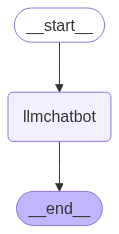

In [44]:
### Visualize the Graph

from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
        
    

In [45]:
response=graph.invoke({"messages":'Hi'})

In [46]:
response["messages"][-1].content

"Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [47]:
for event in graph.stream({"messages":"Hi How are you"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hi! I'm just a language model, I don't have emotions or feelings like humans do, so I don't have a personal experience of being "good" or "bad". I'm just here to help answer your questions and provide information to the best of my ability. How can I assist you today?


### Chatbot with Tool

In [48]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': 'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. By managing the flow of data and the sequence of operations, LangGraph allows developers to focus on the high-level logic of their applications rather than the intricacies of agent coordination. Whether you need a chatbot that can handle various types of user requests or a multi-agent system that performs complex tasks, LangGraph provides the tools to build exactly what you need. LangGraph significantly simplifies the development of complex LLM applications by providing a structured framework for managing state and coordinating agent interaction

In [49]:
## Custom Function
def multiply(a:int,b:int)->int:
    """ Multiply  a and b
    Args:
        a(int):first int
        b(int):second int  
    
    Returns:
        int:output int 
    
    """
    return a*b

In [50]:
tools=[tool,multiply]

In [51]:
llm_with_tool=llm.bind_tools(tools)
 

In [52]:
llm_with_tool 

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001AD5B6BFDD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD5B6BFBF0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list 

In [53]:
### Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":llm_with_tool.invoke(state['messages'])}
## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm" ,
  # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  #if the latest message (result) from assistant is a not a tool call -> tools_condiiton routes to END
  tools_condition     
)
builder.add_edge("tools",END)

## compile the graph

graph=builder.compile()



 

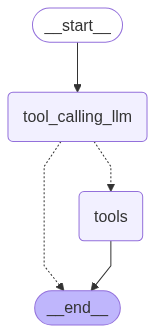

In [54]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [55]:
response=graph.invoke({"messages":"What is the recent AI news "})

In [56]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-openai-gpt-5-draws-musk-eyeroll", "title": "Fox News AI Newsletter: OpenAI GPT-5 draws Musk eyeroll - Fox News", "score": 0.7045877, "published_date": "Fri, 08 Aug 2025 18:58:56 GMT", "content": "- Small business AI adoption jumps to 68% as owners plan significant workforce growth in 2025\\n\\n- McDonald\'s plans AI expansion to streamline customer orders, executive says\\n\\nImage 22: Sam Altman and the Paul brothers\\n\\nOpen AI CEO Sam Altman, center, speaks with boxer Jake Paul and wrestler Logan Paul in Emancipation Hall at the 60th Presidential Inauguration, Monday, Jan. 20, 2025, at the U.S. Capitol in Washington.(Al Drago/Pool Photo via AP) [...] RED THREAT: The U.S. is the global leader in artificial intelligence, but a new report shows China is rapidly expanding its development.\\n\\nTECH UPGRADE: McDonald’s is ramping up its 

In [57]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vfmvnvt3b)
 Call ID: vfmvnvt3b
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-openai-gpt-5-draws-musk-eyeroll", "title": "Fox News AI Newsletter: OpenAI GPT-5 draws Musk eyeroll - Fox News", "score": 0.7045877, "published_date": "Fri, 08 Aug 2025 18:58:56 GMT", "content": "- Small business AI adoption jumps to 68% as owners plan significant workforce growth in 2025\n\n- McDonald's plans AI expansion to streamline customer orders, executive says\n\nImage 22: Sam Altman and

In [58]:
response=graph.invoke({"messages":"what is 2 multiplied by 3 "})
for response in response['messages']:
    response.pretty_print()
    

================================ Human Message =================================

what is 2 multiplied by 3 
================================== Ai Message ==================================
Tool Calls:
  multiply (bps9yaem0)
 Call ID: bps9yaem0
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [59]:
response=graph.invoke({"messages":"what is 5 multiplied by 2 and then multiply 10"})  
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

what is 5 multiplied by 2 and then multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (e3mem1ys5)
 Call ID: e3mem1ys5
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [60]:
response=graph.invoke({"messages":"Give me  the recent ai news and then multiply 5 by 10 "})  
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

Give me  the recent ai news and then multiply 5 by 10 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xa849x5kw)
 Call ID: xa849x5kw
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marktechpost.com/2025/08/10/ai-agent-trends-of-2025-a-transformative-landscape/", "title": "AI Agent Trends of 2025: A Transformative Landscape - MarkTechPost", "content": "Asif Razzaq is the CEO of Marktechpost Media Inc.. As a visionary entrepreneur and engineer, Asif is committed to harnessing the potential of Artificial Intelligence for social good. His most recent endeavor is the launch of an Artificial Intelli

### ReAct Agent Architecture

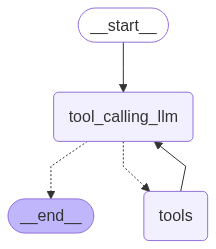

In [61]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3cfpgshy7)
 Call ID: 3cfpgshy7
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://gizmodo.com/a-kentucky-town-experimented-with-ai-the-results-were-stunning-2000641233", "title": "A Kentucky Town Experimented With AI. The Results Were Stunning - Gizmodo", "score": 0.6811549, "published_date": "Sun, 10 Aug 2025 22:34:47 GMT", "content": "Image 9: A computer showing OpenAI's logoTech News Artificial Intelligence After a Summer of Chaos, OpenAI Strikes Back --------------------------------

# Adding Memory in Agentic Graph

In [66]:
response=graph.invoke({"messages":"Hello my name is Nishchal"}) 
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Nishchal
================================== Ai Message ==================================

Nice to meet you, Nishchal!


In [67]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<tool-use>\n{\n    "tool_call": {\n        "id": "pending",\n        "type": "function",\n        "function": {\n            "name": "tavily_search",\n            "parameters": {\n                "query": "What is my name",\n                "topic": "general"\n            }\n        }\n    }\n}\n</tool-use>'}}

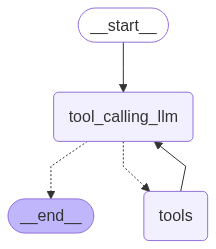

In [73]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [74]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Nishchal"},config=config)

response


{'messages': [HumanMessage(content='Hi my name is Nishchal', additional_kwargs={}, response_metadata={}, id='9ded9868-b4b8-4971-87c6-44721167afb6'),
  AIMessage(content='Nice to meet you, Nishchal! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 2872, 'total_tokens': 2889, 'completion_time': 0.011562338, 'prompt_time': 0.322349476, 'queue_time': 0.266527484, 'total_time': 0.333911814}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--83c2d598-fbf9-4f9c-9b08-48bc689a5606-0', usage_metadata={'input_tokens': 2872, 'output_tokens': 17, 'total_tokens': 2889})]}

In [75]:
response['messages'][-1].content

'Nice to meet you, Nishchal! How can I assist you today?'

In [77]:
response=graph.invoke({'messages':"Hey what is my name?"},config=config)
print(response['messages'][-1].content)

Your name is Nishchal!


In [78]:
response=graph.invoke({'messages':"Hey,do you remember my name?"},config=config)
print(response['messages'][-1].content)

Yes, your name is Nishchal!


## Streaming in LangGraph

In [79]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [81]:
def superbot(state:State):
    return {'messages':[llm_with_tool.invoke(state['messages'])]}

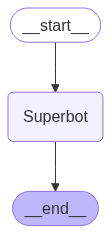

In [82]:
graph=StateGraph(State)

##node
graph.add_node("Superbot",superbot)

#edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [83]:
## Invocation
config={"configurable":{"thread_id":"1"}}

graph_builder.invoke({'messages':'Hi,My name is Nishchal and I like cricket'},config=config)

{'messages': [HumanMessage(content='Hi,My name is Nishchal and I like cricket', additional_kwargs={}, response_metadata={}, id='083421ae-ed92-4c7d-bacc-5c271bdb50ce'),
  AIMessage(content="Nice to meet you, Nishchal! It's great to hear that you like cricket. What's your favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 2877, 'total_tokens': 2905, 'completion_time': 0.020002953, 'prompt_time': 0.341595535, 'queue_time': 0.268121955, 'total_time': 0.361598488}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--46f8fa4d-dfb5-4e05-9613-efec6e588b06-0', usage_metadata={'input_tokens': 2877, 'output_tokens': 28, 'total_tokens': 2905})]}

## Streaming
Methods:stream() and astream()
- These methods are sync and async methods for streaming  back results

### Additional parameters in streaming modes for graph state
- values: This streams the full state  of the graph after each node  is called.
- updates: This streams updates to  the state of graph after each node is called.


In [85]:
config={'configurable':{'thread_id':'3'}}

for chunk in graph_builder.stream({'messages':"Hi,my name is Nishchal and I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Nice to meet you, Nishchal! Cricket is a great interest!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 2945, 'total_tokens': 2961, 'completion_time': 0.011606223, 'prompt_time': 0.32610976, 'queue_time': 0.269148011, 'total_time': 0.337715983}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_5b339000ab', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--a43e48b9-ebb9-4e7c-ab21-1f532cc5baff-0', usage_metadata={'input_tokens': 2945, 'output_tokens': 16, 'total_tokens': 2961})]}}


In [86]:
config={'configurable':{'thread_id':'3'}}

for chunk in graph_builder.stream({'messages':"Hi,my name is Nishchal and I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,my name is Nishchal and I like cricket ', additional_kwargs={}, response_metadata={}, id='3e59b701-e6f7-4a14-abd0-681cc2b749b5'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '58qrz33qy', 'function': {'arguments': '{"query":"cricket","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 2878, 'total_tokens': 2951, 'completion_time': 0.052250649, 'prompt_time': 0.324450275, 'queue_time': 0.266814674, 'total_time': 0.376700924}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_5b339000ab', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--2cdd1450-fd5f-484c-b16a-e4479c681feb-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'cricket', 'search_depth': 'advanced'}, 'id': '58qrz33qy', 'type': 'tool_call'}], usage_metadata={'input_tokens': 2878, 'output_tokens': 73, 'total_tokens'

In [87]:
config={'configurable':{'thread_id':'4'}}

for chunk in graph_builder.stream({'messages':"Hi,my name is Nishchal and I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,my name is Nishchal and I like cricket', additional_kwargs={}, response_metadata={}, id='1dddcce2-7589-4ec6-9103-3083ae4d9877')]}
{'messages': [HumanMessage(content='Hi,my name is Nishchal and I like cricket', additional_kwargs={}, response_metadata={}, id='1dddcce2-7589-4ec6-9103-3083ae4d9877'), AIMessage(content="Nice to meet you, Nishchal! Cricket is a fantastic sport. What's your favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2877, 'total_tokens': 2901, 'completion_time': 0.018049674, 'prompt_time': 0.318380692, 'queue_time': 0.266607068, 'total_time': 0.336430366}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--52aab825-4df7-494c-a934-67392d6e54ac-0', usage_metadata={'input_tokens': 2877, 'output_tokens': 24, 'total_tokens': 2901})]}


In [88]:
config={'configurable':{'thread_id':'5'}}

for chunk in graph_builder.stream({'messages':"Hi,my name is Nishchal and I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Nishchal! Cricket is a fantastic sport, isn't it? What's your favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 2877, 'total_tokens': 2905, 'completion_time': 0.021139405, 'prompt_time': 0.340561594, 'queue_time': 0.390546806, 'total_time': 0.361700999}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--f7b7f074-9fbe-4777-966b-bc11d17c50c0-0', usage_metadata={'input_tokens': 2877, 'output_tokens': 28, 'total_tokens': 2905})]}}


In [90]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,my name is Nishchal and I like cricket', additional_kwargs={}, response_metadata={}, id='93071f7d-a8db-497b-b4fd-c36a658b2742'), AIMessage(content="Nice to meet you, Nishchal! Cricket is a fantastic sport, isn't it? What's your favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 2877, 'total_tokens': 2905, 'completion_time': 0.021139405, 'prompt_time': 0.340561594, 'queue_time': 0.390546806, 'total_time': 0.361700999}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--f7b7f074-9fbe-4777-966b-bc11d17c50c0-0', usage_metadata={'input_tokens': 2877, 'output_tokens': 28, 'total_tokens': 2905}), HumanMessage(content='I also like football', additional_kwargs={}, response_metadata={}, id='0766ccb4-e217-443e-bb98-42b7ef1db0ec'), AIMessage(content='A sports enthusiast! Both cricket a

In [91]:
config={"configurable":{"thread_id":"5"}}
async for event in graph_builder.astream_events({"messages":["Hi My name is Nishchal  and I like  to play cricket."]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Nishchal  and I like  to play cricket.']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '5b99c1fa-de8c-4fd6-9af8-eda48f775daf', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,my name is Nishchal and I like cricket', additional_kwargs={}, response_metadata={}, id='93071f7d-a8db-497b-b4fd-c36a658b2742'), AIMessage(content="Nice to meet you, Nishchal! Cricket is a fantastic sport, isn't it? What's your favorite team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 2877, 'total_tokens': 2905, 'completion_time': 0.021139405, 'prompt_time': 0.340561594, 'queue_time': 0.390546806, 'total_time': 0.361700999}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_0fb809dba3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--f7b7f074-9fbe

## Human in the Loop

In [94]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama3-8b-8192")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001AD5BF20CB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AD5C0C0DA0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [96]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [97]:
memory=MemorySaver()

graph=graph_builder.compile(checkpointer=memory)


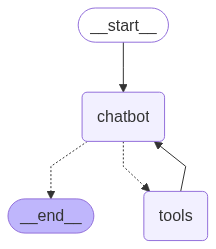

In [98]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [99]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (2myrkjjd6)
 Call ID: 2myrkjjd6
  Args:
    query: expert guidance and assistance for building an AI agent


In [100]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (2myrkjjd6)
 Call ID: 2myrkjjd6
  Args:
    query: expert guidance and assistance for building an AI agent
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Thank you for the assistance! I would like to proceed with LangGraph. Could you please provide more information about LangGraph, such as its features, advantages, and any specific considerations I should keep in mind when using it?
